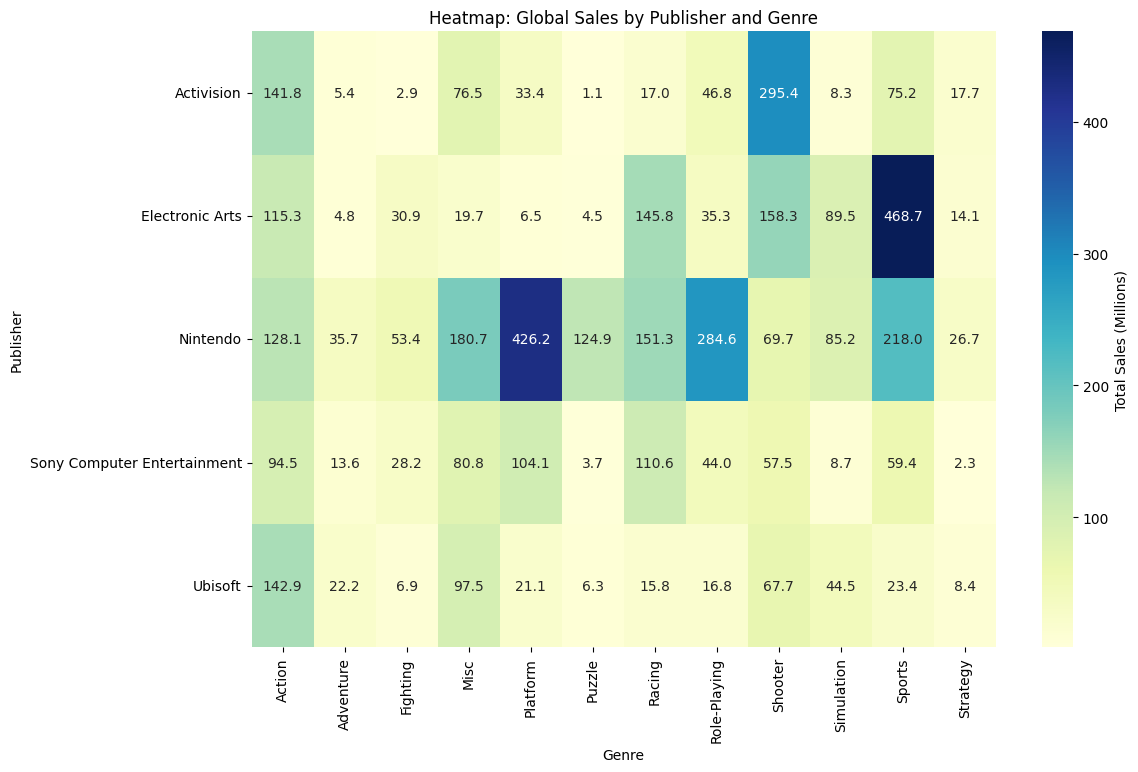

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # For the professional heatmap

df = pd.read_csv('../data/vgsales_cleaned.csv')

# HYPOTHESIS: Specific publishers dominate specific genres 
# (e.g., Nintendo owns Platformers, EA owns Sports)

# 1. Filter for the Top 5 Publishers by total sales
top_publishers = df.groupby('Publisher')['Global_Sales'].sum().nlargest(5).index
filtered_df = df[df['Publisher'].isin(top_publishers)]

# 2. Create a Pivot Table (A core Pandas skill)
# This sums up Global_Sales for every Genre/Publisher combination
pivot_table = filtered_df.pivot_table(index='Publisher', columns='Genre', values='Global_Sales', aggfunc='sum').fillna(0)

# 3. Visualization: Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Total Sales (Millions)'})
plt.title('Heatmap: Global Sales by Publisher and Genre')
plt.savefig("../figures/heatmap.png")  # Save before showing
plt.show()